# Polysemantic Autoencoder for LLMs - The Harry Potter Neuron

Idea

LLMs develop polysemantic neurons with a single neuron responding to multiple unrelated concepts. We leverage autoencoders to extract and amplify task-relevant activations—specifically, those linked to Harry Potter themes in a trained model.

Approach

- Train an Autoencoder: Learn a compressed representation of LLM activations.
- Feature Extraction: Identify neurons correlated with Harry Potter-related tokens.
- Boosting Mechanism: Modify activations at inference time to shift the probability distribution to Harry Potter texts

Why?

- Improves thematic consistency for specialized text generation.
- Provides insight into how polysemantic neurons encode concepts.
- Demonstrates targeted activation manipulation for fine-tuning models without retraining.


## Data Preperation

In [1]:
#Load Data
import csv

hp_texts = []
generic_texts = []

with open("data.csv", "r", encoding="utf-8") as file:
    reader = csv.DictReader(file)
    for row in reader:
        if row["label"] == "harry_potter":
            hp_texts.append(row["text"])
        elif row["label"] == "generic":
            generic_texts.append(row["text"])

print("Harry Potter Texts:", len(hp_texts))
print("Generic Texts:",  len(generic_texts))


Harry Potter Texts: 85
Generic Texts: 85


## Auto Encoder

In [ ]:
#hyperparams
model_name = "distilgpt2"
num_epochs = 1000
num_top_neurons = 3
latent_dim = 64

/Users/thore/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/thore/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/thore/Library/Python/3.9/lib/python/site-packages/transformers/models/auto/modeling_auto.py:1862: FutureWarning: The class `AutoModelWithLMHead` is deprecated and will be removed in a future version. Please use `AutoModelForCausalLM` for causal language models, `AutoModelForMaskedLM` for masked language models and `AutoModelForSeq2SeqLM` for encoder-decoder models.
  warnings.warn(


Epoch 100/1000, Loss: 4.495456
Epoch 200/1000, Loss: 3.573550
Epoch 300/1000, Loss: 0.479952
Epoch 400/1000, Loss: 0.363853
Epoch 500/1000, Loss: 0.441522
Epoch 600/1000, Loss: 0.456614
Epoch 700/1000, Loss: 0.451441
Epoch 800/1000, Loss: 0.406507
Epoch 900/1000, Loss: 0.441649
Epoch 1000/1000, Loss: 0.553006

Top latent neurons (indices) with biggest difference (HP vs Generic):
Neuron 21: Difference 7.5569
Neuron 0: Difference -5.1098
Neuron 36: Difference -5.0493


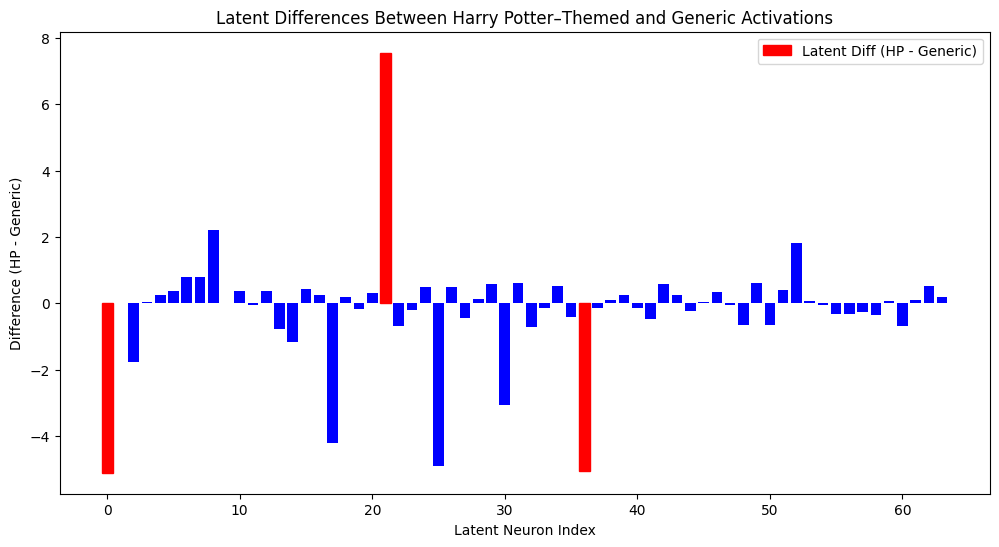

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelWithLMHead

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------------
# 1. Define the Autoencoder Model (unchanged)
# -------------------------------
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, input_dim // 2),
            nn.ReLU(),
            nn.Linear(input_dim // 2, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, input_dim // 2),
            nn.ReLU(),
            nn.Linear(input_dim // 2, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon

# -------------------------------
# 2. Load the Pretrained Model and Tokenizer
# -------------------------------
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelWithLMHead.from_pretrained(model_name)
model.to(device)
model.eval()

# -------------------------------
# 3. (Existing) Function to Extract Activations (for training the autoencoder)
# -------------------------------
def extract_activation(text, model, tokenizer, layer_index=3):
    inputs = tokenizer(text, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
    hidden_states = outputs.hidden_states[layer_index]
    activation = hidden_states.mean(dim=1).squeeze(0)
    return activation.cpu()


hp_activations = [extract_activation(text, model, tokenizer) for text in hp_texts]
generic_activations = [extract_activation(text, model, tokenizer) for text in generic_texts]

hp_activations = torch.stack(hp_activations)        
generic_activations = torch.stack(generic_activations)  
all_activations = torch.cat([hp_activations, generic_activations], dim=0)

# -------------------------------
# 5. Train the Autoencoder (as before)
# -------------------------------
input_dim = all_activations.size(1)
autoencoder = Autoencoder(input_dim, latent_dim).to(device)
dataset = TensorDataset(all_activations)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)
optimizer = optim.Adam(autoencoder.parameters(), lr=1e-3)
criterion = nn.MSELoss()

autoencoder.train()
for epoch in range(num_epochs):
    epoch_loss = 0.0
    for batch in dataloader:
        x = batch[0].to(device)
        optimizer.zero_grad()
        recon = autoencoder(x)
        loss = criterion(recon, x)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * x.size(0)
    if (epoch + 1) % 100 == 0:
        avg_loss = epoch_loss / len(dataset)
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.6f}")

# -------------------------------
# 6. Analyze and Visualize Latent Representations (unchanged)
# -------------------------------
autoencoder.eval()
with torch.no_grad():
    hp_latents = autoencoder.encoder(hp_activations.to(device)).cpu()
    generic_latents = autoencoder.encoder(generic_activations.to(device)).cpu()

hp_mean = hp_latents.mean(dim=0)
generic_mean = generic_latents.mean(dim=0)
latent_diff = hp_mean - generic_mean

_, top_indices = torch.topk(latent_diff.abs(), num_top_neurons)
print("\nTop latent neurons (indices) with biggest difference (HP vs Generic):")
for idx in top_indices.tolist():
    print(f"Neuron {idx}: Difference {latent_diff[idx].item():.4f}")

plt.figure(figsize=(12, 6))
all_indices = range(latent_dim)
bars = plt.bar(all_indices, latent_diff.numpy(), color='blue', label='Latent Diff (HP - Generic)')
for idx in top_indices.tolist():
    bars[idx].set_color('red')
plt.xlabel('Latent Neuron Index')
plt.ylabel('Difference (HP - Generic)')
plt.title('Latent Differences Between Harry Potter–Themed and Generic Activations')
plt.legend()
plt.savefig("laten.png", dpi=300)
plt.show()


## Evaluation

In [3]:
#hyperparms
boost_factor = 1.01
alpha = 0.01

/Users/thore/Library/Python/3.9/lib/python/site-packages/transformers/models/auto/modeling_auto.py:1862: FutureWarning: The class `AutoModelWithLMHead` is deprecated and will be removed in a future version. Please use `AutoModelForCausalLM` for causal language models, `AutoModelForMaskedLM` for masked language models and `AutoModelForSeq2SeqLM` for encoder-decoder models.
  warnings.warn(
/Users/thore/Library/Python/3.9/lib/python/site-packages/transformers/generation/configuration_utils.py:650: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `1` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


Average probability for interest tokens (Original) over all runs: 0.7561426981285747
Average probability for interest tokens (Boosted) over all runs: 0.7249737749733622

Per-Interest-Token Average Probabilities Across All Prompts:
Keyword: 'harry' | Original Avg Prob: 0.0000 (n=0) | Boosted Avg Prob: 0.2975 (n=7)
Keyword: 'potter' | Original Avg Prob: 0.0000 (n=0) | Boosted Avg Prob: 0.8563 (n=7)
Keyword: 'wizard' | Original Avg Prob: 0.7498 (n=17) | Boosted Avg Prob: 0.8001 (n=10)
Keyword: 'magic' | Original Avg Prob: 0.7589 (n=39) | Boosted Avg Prob: 0.7589 (n=39)


/var/folders/7w/mkd8r9995nzdpp6zj2smrw580000gn/T/ipykernel_41369/1360248477.py:230: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(all_orig_interest_probs, label='Original (Interest Tokens)', shade=True)
/var/folders/7w/mkd8r9995nzdpp6zj2smrw580000gn/T/ipykernel_41369/1360248477.py:232: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(all_boost_interest_probs, label='Boosted (Interest Tokens)', shade=True)


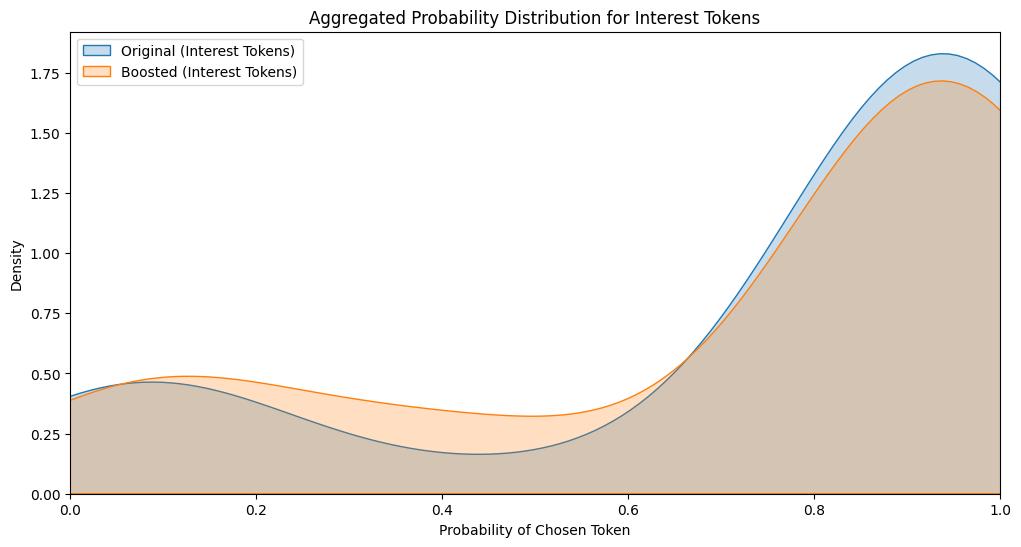

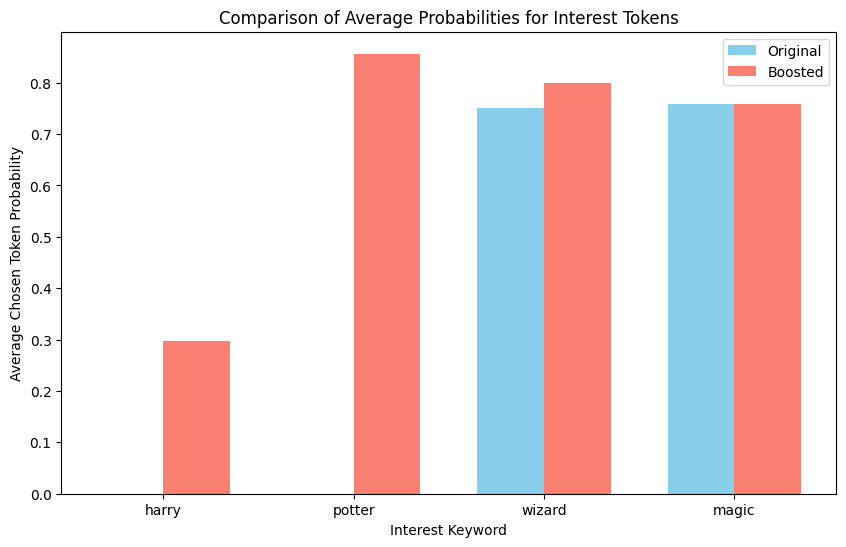

In [14]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelWithLMHead

# -------------------------------
# Setup: Determinism Configuration
# -------------------------------
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# -------------------------------
# Setup: Model and Tokenizer
# -------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = "distilgpt2"

# Load tokenizer with proper padding configuration
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token  # Explicitly set pad token

# Load model with deterministic settings
model = AutoModelWithLMHead.from_pretrained(model_name)
model.to(device)
model.eval()  # Ensure dropout layers are disabled

# -------------------------------
# Generation Configuration
# -------------------------------
generation_config = {
    "pad_token_id": tokenizer.eos_token_id,  # Explicit pad token ID
    "do_sample": False,  # Disable sampling for determinism
    "num_beams": 1,  # Use greedy search
    "temperature": 1.0,  # Neutral temperature
    "top_k": 1,  # Only consider top token
    "top_p": 1.0,  # Disable nucleus sampling
}

# -------------------------------
# Improved Boosting Hook (for visualization and generation)
# -------------------------------
def improved_boost_hook(module, input, output):
    if isinstance(output, tuple):
        hidden = output[0]
        other_outputs = output[1:]
    else:
        hidden = output
        other_outputs = None

    batch, seq_len, hidden_dim = hidden.shape
    hidden_flat = hidden.view(-1, hidden_dim)
    z = autoencoder.encoder(hidden_flat)
    z_boosted = z.clone()
    z_boosted[:, top_indices.to(z.device)] *= boost_factor
    boosted_hidden_flat = autoencoder.decoder(z_boosted)
    new_hidden_flat = (1 - alpha) * hidden_flat + alpha * boosted_hidden_flat
    new_hidden = new_hidden_flat.view(batch, seq_len, hidden_dim)
    return (new_hidden, *other_outputs) if other_outputs else new_hidden

# -------------------------------
# Helper: Generation with Scores
# -------------------------------
def generate_with_scores(input_ids, attention_mask, max_new_tokens=100, **gen_kwargs):
    return model.generate(
        input_ids,
        attention_mask=attention_mask,
        max_length=input_ids.shape[1] + max_new_tokens,
        output_scores=True,
        return_dict_in_generate=True,
        **generation_config
    )


# -------------------------------
# Helper: Token Matching Function
# -------------------------------
interest_keywords = ["harry", "potter", "wizard", "magic"]

def token_matches(token_str, keywords):
    token_str = token_str.lower()
    return any(kw in token_str for kw in keywords)

# -------------------------------
# Evaluaton prompts
# -------------------------------
prompts = [
    "In the magical corridors of Hogwarts, ",
    "As the wizarding world faced a new threat, ",
    "In a mysterious castle filled with enchantments, ",
    "At the bustling Diagon Alley, ",
    "Within the ancient library of magic, ",
    "The legendary tale of a young wizard begins in ",
    "A secret meeting of wizards convened in ",
    "During a dark and stormy night at Hogwarts, ",
    "In the enchanted forest near the school, ",
    "On a quest for a rare magical artifact, ",
    "Today Hogwarts",
    "I feel Snape",
    "The corridor ",
]

# -------------------------------
# Data containers
# -------------------------------
all_orig_interest_probs = []
all_boost_interest_probs = []
all_orig_texts = []
all_boost_texts = []
keyword_stats = {kw: {"Original": [], "Boosted": []} for kw in interest_keywords}

# -------------------------------
# Benchmarking Loop
# -------------------------------
for prompt in prompts:
    inputs = tokenizer(prompt, return_tensors='pt').to(device)
    input_ids = inputs.input_ids
    attention_mask = inputs.attention_mask
    prompt_length = input_ids.shape[1]

    # Original Generation
    orig_output = generate_with_scores(
        input_ids,
        attention_mask,
        max_new_tokens=100,
        top_k=50,
        top_p=0.95,
        temperature=0.8
    )
    
    # Process original output
    orig_sequence = orig_output.sequences[0]
    orig_scores = orig_output.scores
    orig_token_probs = []
    for i, score in enumerate(orig_scores):
        probs = F.softmax(score, dim=-1)
        token_id = orig_sequence[prompt_length + i].item()
        orig_token_probs.append(probs[0, token_id].item())
    
    # Decode and store original text
    #orig_generated_tokens = orig_sequence[prompt_length:]  # Exclude prompt
    orig_text = tokenizer.decode(orig_sequence, skip_special_tokens=True)
    all_orig_texts.append(orig_text)

    # Boosted Generation
    hook_handles = []
    for layer_idx in [2, 3, 4]:
        handle = model.transformer.h[layer_idx].register_forward_hook(improved_boost_hook)
        hook_handles.append(handle)
        
    boost_output = generate_with_scores(
        input_ids,
        attention_mask,
        max_new_tokens=100,
        top_k=50,
        top_p=0.95,
        temperature=0.8
    )
    
    # Remove hooks immediately after generation
    for handle in hook_handles:
        handle.remove()

    # Processing boosted output
    boost_sequence = boost_output.sequences[0]
    boost_scores = boost_output.scores
    boost_token_probs = []
    for i, score in enumerate(boost_scores):
        probs = F.softmax(score, dim=-1)
        token_id = boost_sequence[prompt_length + i].item()
        boost_token_probs.append(probs[0, token_id].item())
    
    # Decode and store boosted text
    #boost_generated_tokens = boost_sequence[prompt_length:]  # Exclude prompt
    boost_text = tokenizer.decode(boost_sequence, skip_special_tokens=True)
    all_boost_texts.append(boost_text)

    
    # Token analysis
    for prob, token_id in zip(orig_token_probs, orig_sequence[prompt_length:]):
        token_str = tokenizer.decode(token_id)
        if token_matches(token_str, interest_keywords):
            all_orig_interest_probs.append(prob)
            for kw in interest_keywords:
                if kw in token_str.lower():
                    keyword_stats[kw]["Original"].append(prob)
    
    for prob, token_id in zip(boost_token_probs, boost_sequence[prompt_length:]):
        token_str = tokenizer.decode(token_id)
        if token_matches(token_str, interest_keywords):
            all_boost_interest_probs.append(prob)
            for kw in interest_keywords:
                if kw in token_str.lower():
                    keyword_stats[kw]["Boosted"].append(prob)

# -------------------------------
# Global Aggregated Analysis: Interest Tokens
# -------------------------------
if all_orig_interest_probs:
    avg_orig_interest = sum(all_orig_interest_probs) / len(all_orig_interest_probs)
    print("Average probability for interest tokens (Original) over all runs:",
          avg_orig_interest)
if all_boost_interest_probs:
    avg_boost_interest = sum(all_boost_interest_probs) / len(all_boost_interest_probs)
    print("Average probability for interest tokens (Boosted) over all runs:",
          avg_boost_interest)

# -------------------------------
# Per-Keyword Statistics
# -------------------------------
print("\nPer-Interest-Token Average Probabilities Across All Prompts:")
for kw in interest_keywords:
    orig_vals = keyword_stats[kw]["Original"]
    boost_vals = keyword_stats[kw]["Boosted"]
    avg_orig = sum(orig_vals)/len(orig_vals) if orig_vals else 0
    avg_boost = sum(boost_vals)/len(boost_vals) if boost_vals else 0
    print(f"Keyword: '{kw}' | Original Avg Prob: {avg_orig:.4f} (n={len(orig_vals)}) | "
          f"Boosted Avg Prob: {avg_boost:.4f} (n={len(boost_vals)})")

# -------------------------------
# Visualization: KDE Plot for Interest Tokens
# -------------------------------
plt.figure(figsize=(12, 6))
if all_orig_interest_probs:
    sns.kdeplot(all_orig_interest_probs, label='Original (Interest Tokens)', shade=True)
if all_boost_interest_probs:
    sns.kdeplot(all_boost_interest_probs, label='Boosted (Interest Tokens)', shade=True)
plt.xlabel("Probability of Chosen Token")
plt.ylabel("Density")
plt.title("Aggregated Probability Distribution for Interest Tokens")
plt.xlim([0,1])
plt.legend()
plt.savefig("avgdensity1.png", dpi=300)
plt.show()

# -------------------------------
# Visualization: Side-by-Side Bar Chart for Per-Keyword Averages
# -------------------------------
keywords = list(interest_keywords)
orig_avgs = [sum(keyword_stats[kw]["Original"])/len(keyword_stats[kw]["Original"]) if keyword_stats[kw]["Original"] else 0 
             for kw in keywords]
boost_avgs = [sum(keyword_stats[kw]["Boosted"])/len(keyword_stats[kw]["Boosted"]) if keyword_stats[kw]["Boosted"] else 0 
              for kw in keywords]

x = range(len(keywords))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([p - width/2 for p in x], orig_avgs, width=width, label='Original', color='skyblue')
plt.bar([p + width/2 for p in x], boost_avgs, width=width, label='Boosted', color='salmon')
plt.xticks(x, keywords)
plt.xlabel("Interest Keyword")
plt.ylabel("Average Chosen Token Probability")
plt.title("Comparison of Average Probabilities for Interest Tokens")
plt.legend()
plt.savefig("avgdensity2.png", dpi=300)
plt.show()


/var/folders/7w/mkd8r9995nzdpp6zj2smrw580000gn/T/ipykernel_41369/3839443111.py:122: UserWarning: Glyph 12304 (\N{LEFT BLACK LENTICULAR BRACKET}) missing from font(s) DejaVu Sans.
  plt.savefig("combined_analysis.png", dpi=300, bbox_inches='tight')
/var/folders/7w/mkd8r9995nzdpp6zj2smrw580000gn/T/ipykernel_41369/3839443111.py:122: UserWarning: Glyph 12305 (\N{RIGHT BLACK LENTICULAR BRACKET}) missing from font(s) DejaVu Sans.
  plt.savefig("combined_analysis.png", dpi=300, bbox_inches='tight')
/Users/thore/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 12304 (\N{LEFT BLACK LENTICULAR BRACKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/thore/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 12305 (\N{RIGHT BLACK LENTICULAR BRACKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


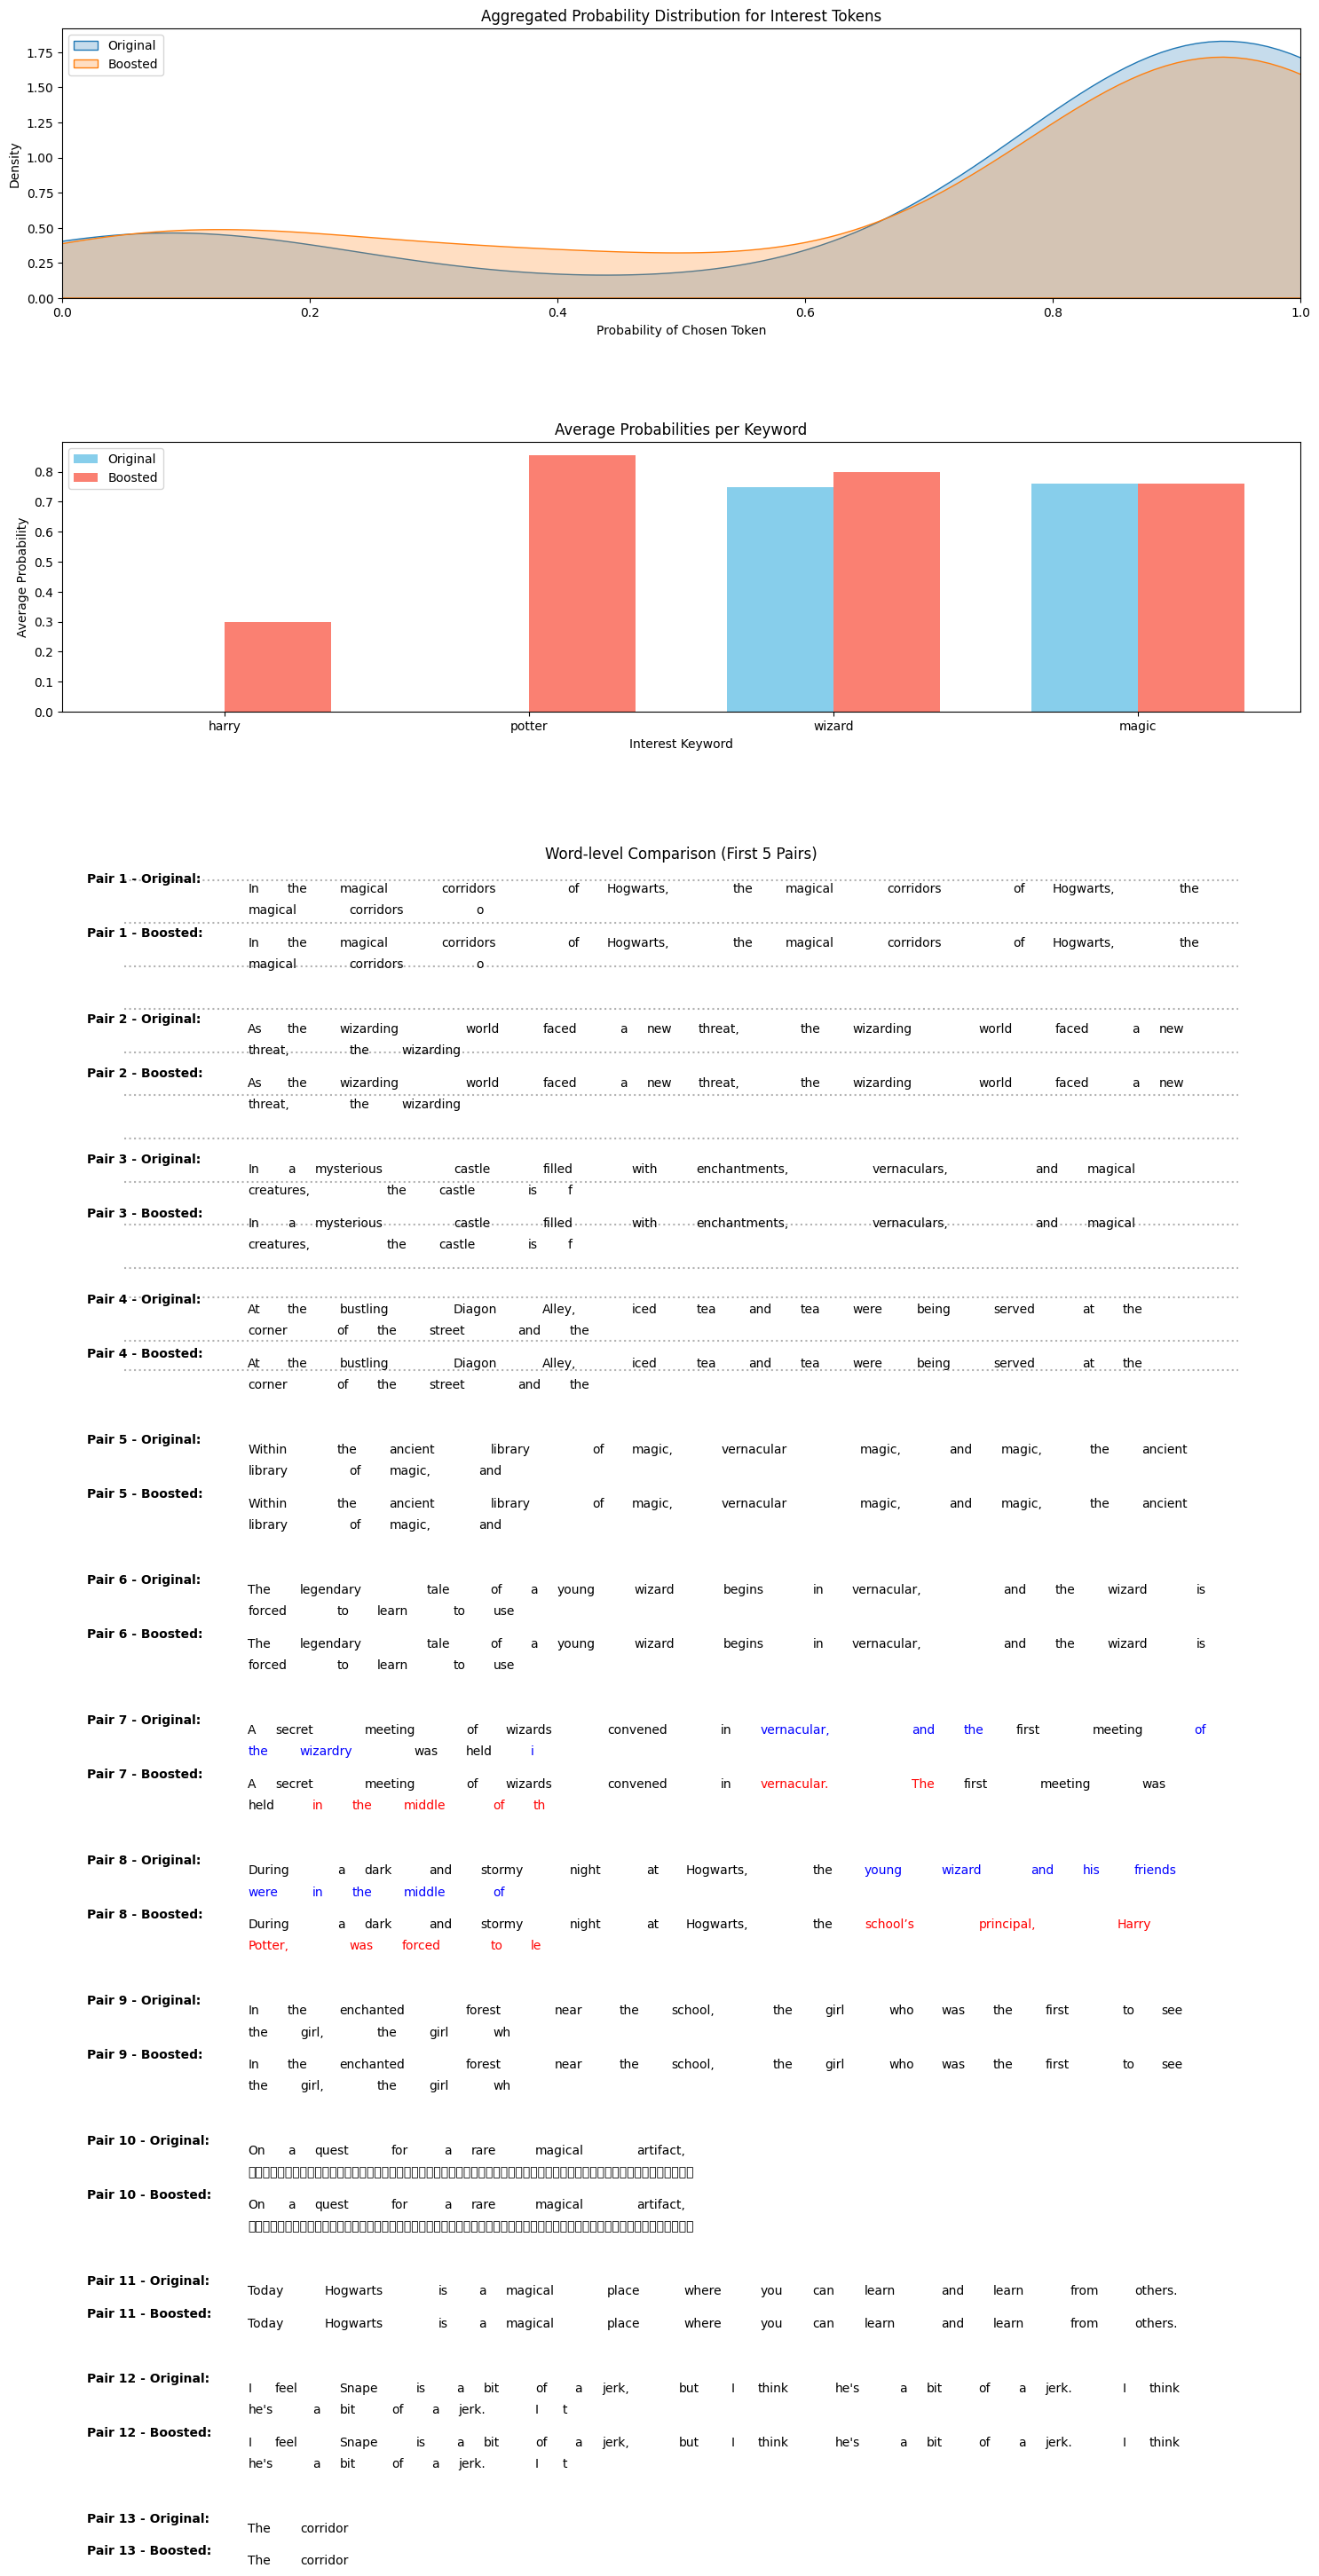

In [17]:
from matplotlib import pyplot as plt
import seaborn as sns
from difflib import SequenceMatcher

# Create figure with subplot grid
fig = plt.figure(figsize=(18, 20))
gs = fig.add_gridspec(3, 1, height_ratios=[1, 1, 2])
plt.subplots_adjust(hspace=0.4)

# --------------------------------------------------
# Subplot 1: KDE Plots (now in first row)
# --------------------------------------------------
ax1 = fig.add_subplot(gs[0])
if all_orig_interest_probs and all_boost_interest_probs:
    sns.kdeplot(all_orig_interest_probs, label='Original', ax=ax1, fill=True)
    sns.kdeplot(all_boost_interest_probs, label='Boosted', ax=ax1, fill=True)
    ax1.set_xlabel("Probability of Chosen Token")
    ax1.set_ylabel("Density")
    ax1.set_title("Aggregated Probability Distribution for Interest Tokens")
    ax1.set_xlim([0,1])
    ax1.legend()

# --------------------------------------------------
# Subplot 2: Bar Chart (now in first row next to KDE)
# --------------------------------------------------
ax2 = fig.add_subplot(gs[1])
if keyword_stats:
    # Calculate positions and widths
    x = range(len(keywords))
    width = 0.35
    
    # Create bars
    ax2.bar([p - width/2 for p in x], orig_avgs, width=width, label='Original', color='skyblue')
    ax2.bar([p + width/2 for p in x], boost_avgs, width=width, label='Boosted', color='salmon')
    
    ax2.set_xticks(x)
    ax2.set_xticklabels(keywords)
    ax2.set_xlabel("Interest Keyword")
    ax2.set_ylabel("Average Probability")
    ax2.set_title("Average Probabilities per Keyword")
    ax2.legend()
from difflib import SequenceMatcher
from difflib import SequenceMatcher
from matplotlib import pyplot as plt

def plot_colored_text(ax, text_parts, x, y, colors, fontsize=10, max_width=0.8):
    """Plot text with word-level coloring using proper character-width calculation"""
    current_x = x
    current_y = y
    char_width = 0.01  # Approximate width per character in axes coordinates
    line_height = 0.04  # Height per line in axes coordinates
    
    for word, color in zip(text_parts, colors):
        # Estimate word width
        word_width = len(word) * char_width
        
        # Check if word fits in current line
        if current_x + word_width > x + max_width:
            current_x = x
            current_y -= line_height
        
        # Plot the word
        ax.text(current_x, current_y, word, 
                color=color, fontsize=fontsize,
                transform=ax.transAxes, ha='left', va='top')
        
        # Update x position (add word width + space)
        current_x += word_width + (char_width * 1.2)  # Add space between words
    
    return current_y - line_height  # Return final y position

# --------------------------------------------------
# Modified Text Comparison Subplot
# --------------------------------------------------
ax3 = fig.add_subplot(gs[2])
ax3.axis('off')
y_pos = 0.95  # Starting Y position

for idx in range(20):
    if idx >= len(all_orig_texts) or idx >= len(all_boost_texts):
        break
    limit = 100
    #if 'harry' in all_boost_texts[idx] or 'Harry' in all_boost_texts[idx] :
    #    limit = 1000
    # Process texts
    orig = all_orig_texts[idx][:limit].replace('\n', ' ')
    boost = all_boost_texts[idx][:limit].replace('\n', ' ')
    
    # Split into words and find differences
    orig_words = orig.split()
    boost_words = boost.split()
    matcher = SequenceMatcher(None, orig_words, boost_words)
    
    # Generate color maps
    orig_colors = ['black'] * len(orig_words)
    boost_colors = ['black'] * len(boost_words)
    
    for tag, i1, i2, j1, j2 in matcher.get_opcodes():
        if tag != 'equal':
            for i in range(i1, i2):
                orig_colors[i] = 'blue'
            for j in range(j1, j2):
                boost_colors[j] = 'red'
    
    # Plot original text
    ax3.text(0.02, y_pos, f"Pair {idx+1} - Original:", 
            fontsize=10, weight='bold', transform=ax3.transAxes)
    final_y = plot_colored_text(ax3, orig_words, 0.15, y_pos, orig_colors)
    
    # Plot boosted text
    ax3.text(0.02, final_y - 0.02, f"Pair {idx+1} - Boosted:", 
            fontsize=10, weight='bold', transform=ax3.transAxes)
    final_y = plot_colored_text(ax3, boost_words, 0.15, final_y - 0.02, boost_colors)
    
    # Add separator
    ax3.axhline(final_y - 0.02, xmin=0.05, xmax=0.95, 
               color='gray', linestyle=':', alpha=0.6)
    
    y_pos = final_y - 0.08  # Update Y position for next pair

ax3.set_title("Word-level Comparison (First 5 Pairs)", y=0.98, fontsize=12)
plt.savefig("combined_analysis.png", dpi=300, bbox_inches='tight')
plt.show()